# INTRODUCTION:

 In this project we explores the application of unsupervised machine learning techniques to analyze and manipulate pictures taken of the milky way galaxy withe the "skymap" function. Altering the images into numpy arrays lets us utilize the K-means clustering algorithms. THe main learning is to identify and categorize different star/brightness populations based on their colors and brightness patterns.

 This project will provide key learnings on manipulating pictures, but from a wider point of view it also shows us how to see that algorithms can reveal patterns that might not be immediately obvious to the human eye. Unlike supervised learning, which requires known training data, unsupervised methods like K-means can discover natural groupings in data automaticly.

 Through a series of progressive tasks, we will:
-Generate multiple views of the milky way from different centers and zoom levels
 -Process images using grayscale conversion and brightness filtering
 -Apply K-means clustering to groups with similar pixels
 -Visualize clustering results

In [26]:
# mw_plot is an astronomy library that is designed to visualize the Milky Way galaxy
### With the installment, packages like numpy, matplolib, astropy etc. also was implemented:)

#!pip install mw_plot       

In [27]:
#pip install astroquery --upgrade

In [4]:
import mw_plot
print("mw_plot has been imported")

mw_plot has been imported


In [21]:
from funct import chocolate_milkyway, plt2rgbarr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.cluster import KMeans
from astropy import units as u
from mw_plot import MWSkyMap

C:\Users\patri\anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## Task 1 

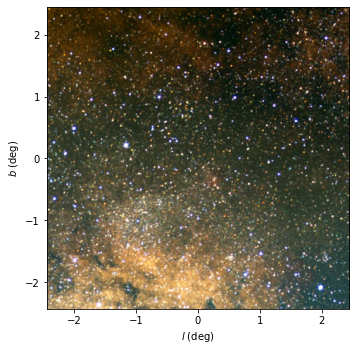

In [6]:
### Had to use coordinates becaus something is wrong with my installment, it wont retreive the strings
mw1 = MWSkyMap(
    center = (10.68, 41.27) * u.arcsec,               
    radius=(8800, 8800) * u.arcsec,
    background="Mellinger color optical survey",
)

fig, ax = plt.subplots(figsize=(5, 5))

mw1.transform(ax)

mw1.savefig('galaxy.png')
plt.show()

## Task 2 (three different visualizations)

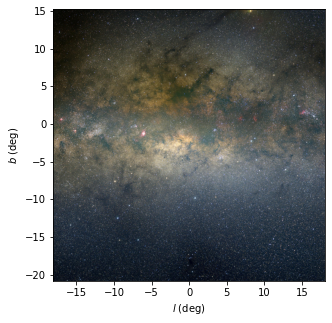

Saved: view1.png


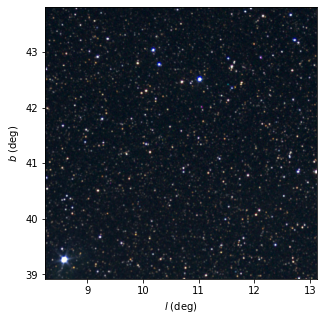

Saved: view2.png


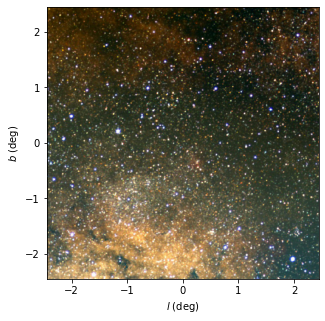

Saved: view3.png


In [7]:
chocolate_milkyway(
    center=(5, -10000),
    radius=(65000, 65000),       ### Call function 1
    title="",                    
    filename="view1.png"
)

chocolate_milkyway(
    center=(38448, 148920),
    radius=(8800, 8800),        ### Call function 2
    title="",                   ### Found online that this was the coordinates for the andromeda
    filename="view2.png"
)

chocolate_milkyway(
    center=(0, 0),
    radius=(8800, 8800),        ### Call function 3
    title="",
    filename="view3.png"
)

## Task 3

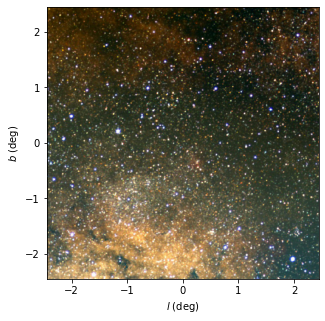

Saved: view1.png
Image shape: (360, 360, 3)
Sample pixel: [5 3 0]


In [11]:
chocolate_milkyway(
    center=(0, 0),
    radius=(8800, 8800),     
    title="",                    
    filename="view1.png"
)

# Convert to RGB array
img_array = plt2rgbarr(fig)

# Check the result
print(f"Image shape: {img_array.shape}")  
print(f"Sample pixel: {img_array[0, 0]}")  # Shows [R, G, B] values

plt.show()

## Task 4

## From task 3 I got an image represented as a numpy array with dimensions (360, 360, 3), meaning 360 rows, 360 columns, and 3 color channels (RGB).

## Step 1 Print the image shape to confirm dimensions

## Step 2: Convert RGB image to grayscale using formula from attached file. The formula i think shows how the human eye see brightness.

## Step 3: Filter bright pixels with an adjustable threshold (now set at 150). Find all pixel positions (x, y) above the brightness limit (stars).

## Step 4: For each bright pixel position, get the original RGB colors from the image. This gives us a list of color values that we can group with K-means.



In [19]:
from matplotlib.colors import ListedColormap

#1.
print(f"original image shape:{img_array.shape} " )  # Meaning: 360 rows × 360 columns × 3 colors (RGB)

#2.
grey = np.sum(img_array[: , : , :] * np.array([0.299, 0.587, 0.114]), axis=2)  # From RGB to grey

#3. 
bright_limit = 150
x, y = [], []
for ig, g in enumerate(grey):                  # from attached file-- A grey encoding
    for ij, j in enumerate(g): 
        if j > bright_limit:
            x.append(ig)
            y.append(ij)     
#4
intensity=[]             # creates a list to store different brightness in pixels 
for xi, yi in zip(x, y):            # Loops through each pair of positions from x and y lists, zip(x, y) combines them
    intensity.append(img_array[xi, yi])       # Get the RGB color at position xi,yi from the original image, and add rgb values to intensity list
intensity = np.array(intensity)            # Converts the list into a numpy array for K-means

original image shape:(360, 360, 3) 


## Task 5

Intensity array shape: (10460, 3)
Clustered 10460 pixels into 3 groups

Cluster distribution:
  Cluster 0: 3106 pixels (29.7%)
  Cluster 1: 5614 pixels (53.7%)
  Cluster 2: 1740 pixels (16.6%)

Cluster centers (RGB):
  Cluster 0: RGB(226, 185, 125)
  Cluster 1: RGB(192, 157, 109)
  Cluster 2: RGB(213, 206, 200)


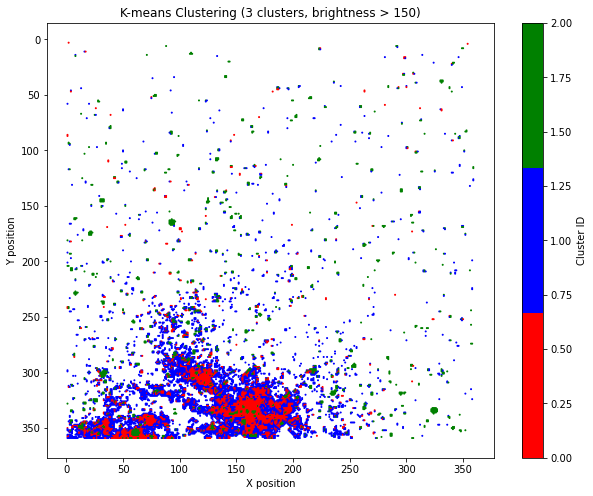

In [23]:
      
print(f"Intensity array shape: {intensity.shape}")      


# apply k-means clustering

n_cluster = 3  
kmeans = KMeans(n_clusters=n_cluster, n_init=10, random_state=30) # for n_cluster find 3 groups, n_init run algorithm 10 times and pick best result
labels = kmeans.fit_predict(intensity)        # fit finds the 3 cluster center, predict itterates through pixels and assigns them to nearest cluster
                                             # array with cluste id (one for each cluster)

    
print(f"Clustered {len(intensity)} pixels into {n_cluster} groups")



# Print cluster info 
print(f"\nCluster distribution:")
for i in range(n_cluster):            ## loops through each cluster
    count = np.sum(labels == i)       #creates array of True/False (True where label equals i), which then counts the Trues (how many pixels in cluster i)
    print(f"  Cluster {i}: {count} pixels ({count/len(labels)*100:.1f}%)")  ##calculates percentage in each cluster


    
print(f"\nCluster centers (RGB):")
for i, center in enumerate(kmeans.cluster_centers_):        # Loops through each cluster center
    print(f"  Cluster {i}: RGB({center[0]:.0f}, {center[1]:.0f}, {center[2]:.0f})")  
    # center[0] = Red, center[1] = Green, center[2] = Blue

    
    
my_colors = ['red', 'blue', 'green']
my_cmap = ListedColormap(my_colors)
    
# Visualize clustering
plt.figure(figsize=(10, 8))
plt.scatter(y, x, c=labels, s=1, cmap=my_cmap)
plt.title(f'K-means Clustering ({n_cluster} clusters, brightness > {bright_limit})')
plt.colorbar(label='Cluster ID')
plt.gca().invert_yaxis()
plt.xlabel('X position')
plt.ylabel('Y position')
plt.show()


## Task 6

Total pixels: 129600
As seen in the photo, everything is just completetely overwhelming with unusable info:


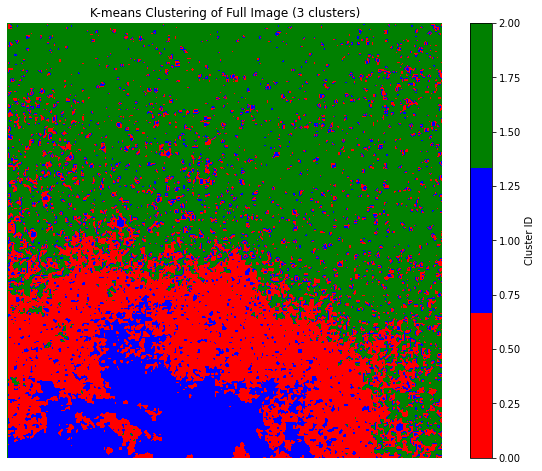

In [25]:
#Reshape ALL pixels (not just bright ones)
all_pixels = img_array.reshape(129600, 3) # Saves dimentions of picture, 360 x 360 with 3 rgb values each


print(f"Total pixels: {len(all_pixels)}")
print(f"As seen in the photo, everything is just completetely overwhelming with unusable info:")

height, width = img_array.shape[0], img_array.shape[1]

# Apply K-means to ALL pixels
kmeans_full = KMeans(n_clusters=n_cluster, n_init=10, random_state=30)
labels_full = kmeans_full.fit_predict(all_pixels)


# reshape labels back to image dimensions
clustered_image = labels_full.reshape(height, width)

plt.figure(figsize=(10, 8))
plt.imshow(clustered_image, cmap=my_cmap)
plt.title(f'K-means Clustering of Full Image ({n_cluster} clusters)')
plt.colorbar(label='Cluster ID')
plt.axis('off')
plt.show()


# Self reflection (Patrick, 277988):

## Throughout this assignment regarding analyzing images with unsupervised learning, espacially images of the Milky Way galaxy, I have learned about image processing and gained insight into how images are represented as numerical arrays (pixels with RGB values) and how to manipulate them programmatically.

## I have discovered that unsupervised learning can find natural patterns in data without being told what to look for (all though i like instructions:). The algorithm automatically groups similar colored pixels, and I understood that there is no "correct" way of setting up the algorithm. It can vary on what you want to analyze, and therefor how you interpret the results. Even with a clear idea of what parameters should be (f.eks, the brightness threshold).

## Personal insight: Initially I struggled with matching code to tasks and understanding what the guidelines for what some of the tasks asked for. However, through experimentation I realized that data manipulation is as much about asking the right questions as it is about technical implementation. In other terms trial and error in the sense that you need to do what you think, and what suits your understanding the best.

# References:

## Riccardi. E, "Sketchbook for galaxy plotter", 2025
## Geeksforgeeks, "What is Grayscale Image?", 23.07.25, https://www.geeksforgeeks.org/electronics-engineering/what-is-grayscale-image/ 
## Geeksforgeeks, "K means Clustering – Introduction", 10.11.25 https://www.geeksforgeeks.org/machine-learning/k-means-clustering-introduction/
## Leung. H., "Welcome to mw-plot’s documentation!" Last updated on 24 Jun 2025. https://milkyway-plot.readthedocs.io/en/stable/#welcome-to-mw-plot-s-documentation

# A statement on the eventual usage of AI:

## For this project I have used AI to help me decode the questions (which reflected on as hard to interpret). As for other task AI has been used to brainstom options when I got stuck on a task. 